### Polynomial Regression

Equation: `y = 5x^3 - 10x^2 - 20x + 10`

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

tf.keras.utils.set_random_seed(4)

In [2]:
# Polynomial function
def polynomial(x):
    return 5 * x**3 - 10 * x**2 - 20 * x + 10


def normalize(values, min_value, max_value):
    return 2 * (values - min_value) / (max_value - min_value) - 1


def denormalize(values, min_value, max_value):
    return (values + 1) * (max_value - min_value) / 2 + min_value


def make_polynomial_features(values):
    values = np.asarray(values).reshape(-1, 1)
    return np.hstack([values, values**2, values**3])

In [3]:
# Generate training data
np.random.seed(4)
x = np.random.uniform(-20, 20, 1000)
y = polynomial(x)

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

x_norm = normalize(x, x_min, x_max)
y_norm = normalize(y, y_min, y_max).reshape(-1, 1)
x_features = make_polynomial_features(x_norm)

print(f"x range: {x_min:.2f} to {x_max:.2f}")
print(f"y range: {y_min:.2f} to {y_max:.2f}")

x range: -19.96 to 19.97
y range: -43359.03 to 35468.24


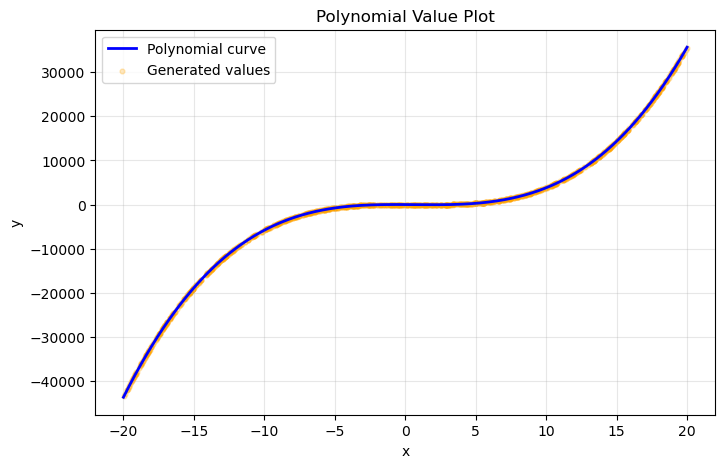

In [4]:
# Plot polynomial values with a smooth curve
x_plot = np.linspace(-20, 20, 500)
y_plot = polynomial(x_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, color="blue", linewidth=2, label="Polynomial curve")
plt.scatter(x, y, color="orange", s=12, alpha=0.25, label="Generated values")
plt.title("Polynomial Value Plot")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

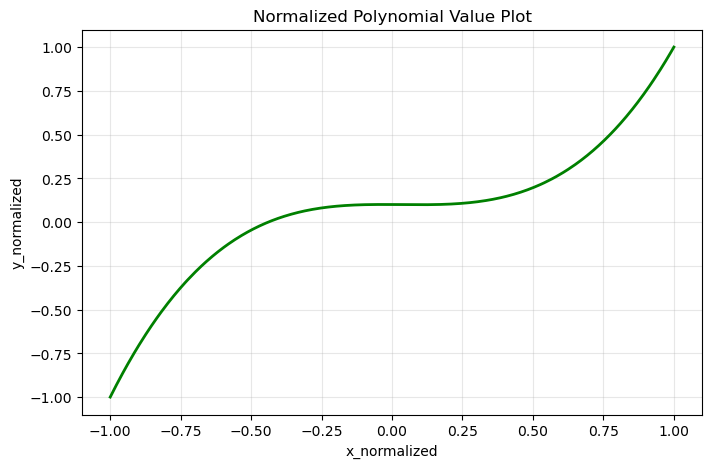

In [5]:
# Plot normalized polynomial values in sorted order
sort_idx = np.argsort(x_norm)

plt.figure(figsize=(8, 5))
plt.plot(x_norm[sort_idx], y_norm[sort_idx], color="green", linewidth=2)
plt.title("Normalized Polynomial Value Plot")
plt.xlabel("x_normalized")
plt.ylabel("y_normalized")
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Build model using x, x^2, and x^3 features
model = tf.keras.Sequential([
    Input(shape=(3,)),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.03),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 4 (16.00 B)
 Trainable params: 4 (16.00 B)
 Non-trainable params: 0 (0.00 B)


In [7]:
# Train model
history = model.fit(
    x_features,
    y_norm,
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print(f"Final training loss: {history.history['loss'][-1]:.12f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.12f}")

Final training loss: 0.000000000000
Final validation loss: 0.000000000000


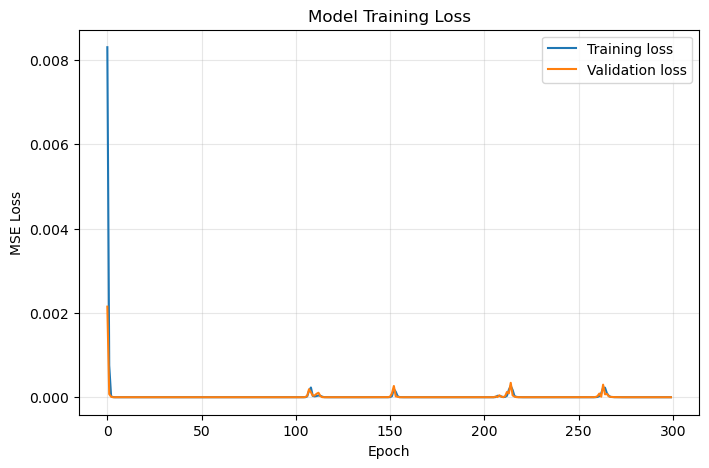

In [8]:
# Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [9]:
# Predictions on training data and original scale
y_pred_norm = model.predict(x_features, verbose=0)
y_pred = denormalize(y_pred_norm, y_min, y_max).reshape(-1)

mae = np.mean(np.abs(y - y_pred))
mse = np.mean((y - y_pred) ** 2)

print(f"MAE on original scale: {mae:.6f}")
print(f"MSE on original scale: {mse:.6f}")

MAE on original scale: 0.010136
MSE on original scale: 0.000143


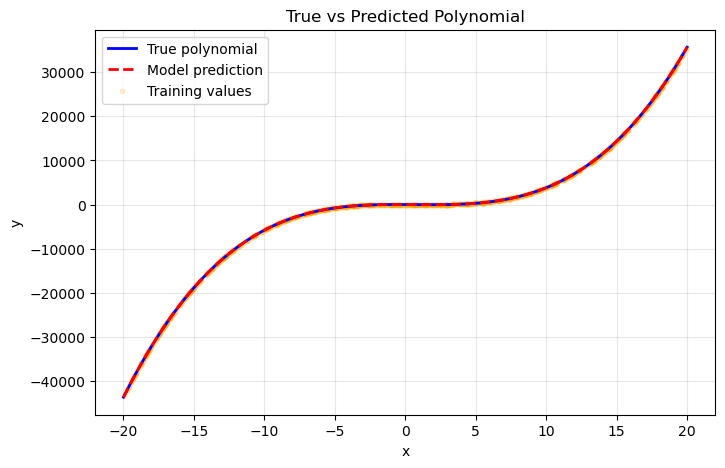

In [10]:
# Compare real polynomial curve and model prediction
x_plot_norm = normalize(x_plot, x_min, x_max)
x_plot_features = make_polynomial_features(x_plot_norm)
y_plot_pred_norm = model.predict(x_plot_features, verbose=0)
y_plot_pred = denormalize(y_plot_pred_norm, y_min, y_max).reshape(-1)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, color="blue", linewidth=2, label="True polynomial")
plt.plot(x_plot, y_plot_pred, color="red", linestyle="--", linewidth=2, label="Model prediction")
plt.scatter(x, y, color="orange", s=10, alpha=0.18, label="Training values")
plt.title("True vs Predicted Polynomial")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [11]:
# Sample predictions
x_sample = np.array([-20, -10, 0, 10, 20], dtype=float)
x_sample_norm = normalize(x_sample, x_min, x_max)
x_sample_features = make_polynomial_features(x_sample_norm)
y_sample_true = polynomial(x_sample)
y_sample_pred_norm = model.predict(x_sample_features, verbose=0)
y_sample_pred = denormalize(y_sample_pred_norm, y_min, y_max).reshape(-1)

print("x\ttrue_y\tpredicted_y")
for x_value, true_value, pred_value in zip(x_sample, y_sample_true, y_sample_pred):
    print(f"{x_value:.0f}\t{true_value:.2f}\t{pred_value:.2f}")

x	true_y	predicted_y
-20	-43590.00	-43590.00
-10	-5790.00	-5790.01
0	10.00	9.98
10	3810.00	3809.99
20	35610.00	35610.03
